<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 164 &middot; Capstone 5 &middot; One-Way ANOVA</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Do Three Teaching Methods Differ?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:790px;line-height:1.6">Three groups, one exam score, and a two-part answer. ANOVA tells us whether any of the methods differ at all; a post-hoc test tells us which ones. A full framework pass, including the reason we do not simply run three t-tests.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, AMBER, DARK, BL, RD, GR, MUT = "#b45309", "#d97706", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"
ORDER = ["Lecture","Blended","Flipped"]
COL = {"Lecture":MUT, "Blended":BL, "Flipped":GOLD}

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-teaching-methods-exam-scores.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="scores")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="scores")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 137 rows


,student_id,method,section,exam_score
0,S293,Flipped,1,83.0
1,S335,flipped,3,70.0
2,S211,Lecture,3,77.0
3,S250,blended,3,79.0
4,S273,Blended,1,67.0


## Step 1 &middot; Goal and hypotheses
A department taught the same course three ways across different sections, Lecture, Blended, and Flipped, and recorded each student's final exam score. The question is whether the teaching method makes a difference to exam performance.

With three groups the hypotheses are about all of them at once.
- **H&#8320; (null):** all three methods have the same mean exam score.
- **H&#8321; (alternative):** at least one method differs from the others.
- **&#945; = 0.05.**

Note what H&#8321; does *not* say: it does not say which method differs, or that all three differ. That is exactly why a significant ANOVA has to be followed by a post-hoc test.

## Step 2 &middot; Know the data types
The outcome, `exam_score`, is **continuous** (0 to 100). The grouping variable, `method`, is **nominal with three levels**. A continuous outcome across three or more independent groups is the home of the **one-way ANOVA**.

In [2]:
print(raw.dtypes)
print("\nmethod labels as they arrived (note the inconsistent casing/spacing):")
print(raw.method.value_counts(dropna=False).to_string())

student_id        str
method            str
section         int64
exam_score    float64
dtype: object

method labels as they arrived (note the inconsistent casing/spacing):
method
lecture     21
Blended     19
Flipped     18
flipped     15
blended     15
Lecture     13
Blended     13
Lecture     12
Flipped     11


**What this shows.** The outcome is numeric and the grouping variable has three levels, but those levels arrived typed six different ways. Left alone, Python would treat `"Flipped"`, `"flipped"`, and `"Flipped "` as separate groups, so standardizing the label is the first cleaning job.

## Step 3 &middot; Describe
Group sizes and summary statistics, before cleaning.

In [3]:
print("rows:", len(raw), " unique students:", raw.student_id.nunique())
print("\nraw exam_score summary:")
print(raw.exam_score.describe().round(2).to_string())

rows: 137  unique students: 135

raw exam_score summary:
count    134.00
mean      75.59
std       12.49
min       -5.00
25%       69.00
50%       76.00
75%       83.00
max      127.00


**What this shows.** There are more rows than unique students (duplicate log entries), and the score range runs beyond the possible 0 to 100 (a 127 and a negative), so the raw summary statistics cannot be trusted yet.

## Step 4 &middot; Visualize first
A boxplot per method, with the individual students drawn beside it, shows both the group centers and the spread of real people behind them.

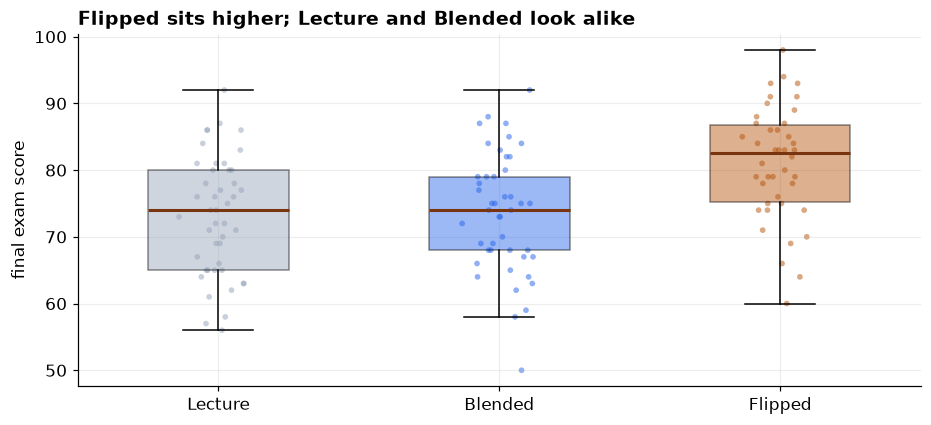

In [4]:
tmp = raw.copy()
tmp["method"] = tmp.method.str.strip().str.title()
tmp = tmp[tmp.exam_score.between(0,100)]
fig, ax = plt.subplots(figsize=(8.6, 4))
data = [tmp[tmp.method==m].exam_score.values for m in ORDER]
bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, widths=0.5, showfliers=False)
for patch, m in zip(bp["boxes"], ORDER): patch.set_facecolor(COL[m]); patch.set_alpha(0.45)
for med in bp["medians"]: med.set_color(DARK); med.set_linewidth(2)
rng = np.random.default_rng(0)
for i, m in enumerate(ORDER, start=1):
    y = tmp[tmp.method==m].exam_score.values
    ax.scatter(rng.normal(i, 0.06, len(y)), y, s=14, alpha=0.5, color=COL[m], edgecolor="none")
ax.set_ylabel("final exam score"); ax.set_title("Flipped sits higher; Lecture and Blended look alike")
plt.tight_layout(); plt.show()

**Reading the plot.** Two of the three boxes sit at almost the same height: Lecture and Blended are hard to tell apart. The Flipped box is clearly lifted above both. That is the pattern the formal tests have to confirm, and it already hints that a significant ANOVA will not mean "all three differ".

## Step 5 &middot; Prepare and clean
Four fixes, in order: **standardize the method label**, drop **duplicate rows**, drop **missing scores**, and drop **impossible scores** (an exam score must lie between 0 and 100).

In [5]:
df = raw.copy()
df["method"] = df.method.str.strip().str.title()
before = len(df)
df = df.drop_duplicates(); after_dup = len(df)
df = df.dropna(subset=["exam_score"]); after_na = len(df)
bad = df[~df.exam_score.between(0,100)]
df = df[df.exam_score.between(0,100)].copy()
print("method labels after cleaning:", sorted(df.method.unique()))
print(f"start {before}  ->  dedup {after_dup} (-{before-after_dup})  ->  dropna {after_na} (-{after_dup-after_na})")
print("impossible scores removed:", sorted(bad.exam_score.tolist()))
print(f"clean analysis sample: n = {len(df)}")
print()
print(df.groupby("method").exam_score.agg(["count","mean","std"]).round(2).reindex(ORDER).to_string())

method labels after cleaning: ['Blended', 'Flipped', 'Lecture']
start 137  ->  dedup 135 (-2)  ->  dropna 132 (-3)
impossible scores removed: [-5.0, 127.0]
clean analysis sample: n = 130

         count   mean   std
method                     
Lecture     45  73.16  8.85
Blended     43  73.53  9.06
Flipped     42  81.10  8.45


**What cleaning cost us.** Six inconsistent labels collapse to three real groups, and 133 rows become 130 usable scores. The group means now read cleanly: Lecture and Blended land within half a point of each other, while Flipped is about seven and a half points higher.

## Step 6 &middot; Name the design
Three **independent** groups of different students, one continuous outcome, one factor (teaching method). This is a **one-way** design: one grouping variable, three levels.

## Step 7 &middot; Check the assumptions
ANOVA asks for two things, the same two as the two-sample t-test: each group roughly **normal**, and the groups sharing a common **variance**. Normality by Shapiro-Wilk and Q-Q plots; equal variance by **Levene's** and **Bartlett's** tests.

Lecture  n= 45  Shapiro-Wilk W=0.981, p=0.659  -> normal enough
Blended  n= 43  Shapiro-Wilk W=0.989, p=0.952  -> normal enough
Flipped  n= 42  Shapiro-Wilk W=0.985, p=0.859  -> normal enough

Levene's test   W = 0.200, p = 0.8190   -> variances look equal
Bartlett's test chi-sq = 0.204, p = 0.9031   -> variances look equal

group SDs: {'Lecture': np.float64(8.85), 'Blended': np.float64(9.06), 'Flipped': np.float64(8.45)}


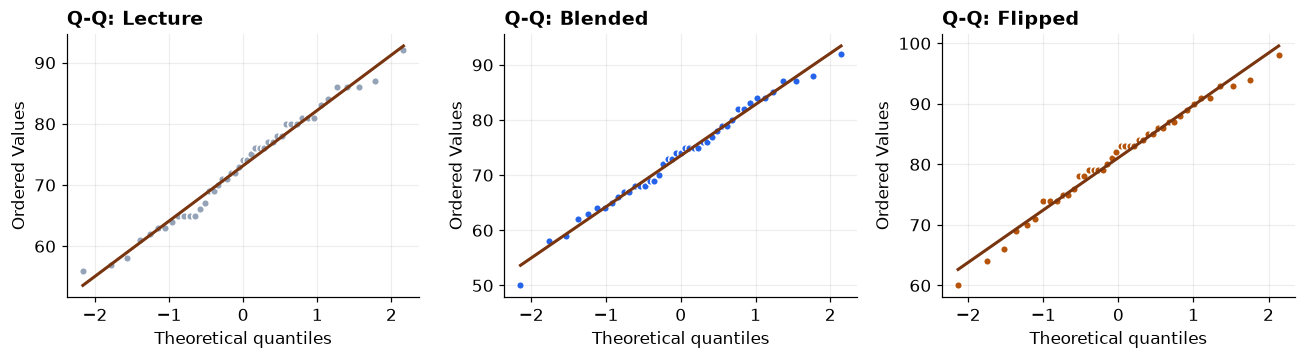

In [6]:
groups = [df[df.method==m].exam_score.values for m in ORDER]
for m, x in zip(ORDER, groups):
    sw = stats.shapiro(x)
    print(f"{m:8s} n={len(x):3d}  Shapiro-Wilk W={sw.statistic:.3f}, p={sw.pvalue:.3f}  -> {'normal enough' if sw.pvalue>0.05 else 'not normal'}")
lev = stats.levene(*groups); bart = stats.bartlett(*groups)
print(f"\nLevene's test   W = {lev.statistic:.3f}, p = {lev.pvalue:.4f}   -> variances {'differ' if lev.pvalue<0.05 else 'look equal'}")
print(f"Bartlett's test chi-sq = {bart.statistic:.3f}, p = {bart.pvalue:.4f}   -> variances {'differ' if bart.pvalue<0.05 else 'look equal'}")
print("\ngroup SDs:", {m: round(x.std(ddof=1),2) for m,x in zip(ORDER,groups)})

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a_, (m, x) in zip(ax, zip(ORDER, groups)):
    stats.probplot(x, dist="norm", plot=a_)
    a_.get_lines()[0].set(marker="o", markerfacecolor=COL[m], markeredgecolor="white", markersize=5)
    a_.get_lines()[1].set(color=DARK, lw=2); a_.set_title(f"Q-Q: {m}")
plt.tight_layout(); plt.show()

**What the diagnostics say.** All three groups pass the normality check comfortably, and the Q-Q points hug their reference lines. The three standard deviations are within half a point of one another, and both Levene and Bartlett agree the variances are equal. Unlike Capstone 2, nothing here forces us off the standard procedure: the classic one-way ANOVA is valid.

## Step 8 &middot; Decide, and the question we have to answer first
Assumptions hold, so we use the **classic one-way ANOVA**. But before running it, it is worth asking why we need ANOVA at all. With three groups we could just run three t-tests: Lecture vs Blended, Lecture vs Flipped, Blended vs Flipped. The reason we do not is the problem from [Capstone 4](../../capstone-heart-disease-markers.html): each test carries its own 5% false-positive risk, so three of them inflate the family-wise error rate to roughly 14%. ANOVA asks the question **once**, at a controlled 5%.

In [7]:
k = 3
print(f"three pairwise t-tests at alpha=0.05 -> family-wise error = 1-(1-0.05)^{k} = {1-(1-0.05)**k:.1%}")
print("one ANOVA                            -> family-wise error =                    5.0%")
print("\nand if ANOVA is significant, Tukey HSD compares every pair while HOLDING the family-wise error at 5%.")

three pairwise t-tests at alpha=0.05 -> family-wise error = 1-(1-0.05)^3 = 14.3%
one ANOVA                            -> family-wise error =                    5.0%

and if ANOVA is significant, Tukey HSD compares every pair while HOLDING the family-wise error at 5%.


**Why this matters.** ANOVA is not merely a convenience for three groups; it is the error-controlled way to ask whether any difference exists. And when we do want the pairwise detail, Tukey's HSD provides it with the same protection built in, which is exactly what an uncorrected set of t-tests lacks.

## Step 9 &middot; Choose the tests
- **Primary:** one-way ANOVA (F-test) for any difference among the three means.
- **Post-hoc:** Tukey HSD, to identify which pairs differ, with the family-wise error controlled.
- **Robustness check:** Kruskal-Wallis, the rank-based twin, which assumes neither normality nor equal variance.
- **Reported alongside:** eta-squared (the share of score variation explained by method) and the confidence intervals on each pairwise difference.

## Step 10 &middot; Run the tests and report fully
We fit the model with `statsmodels` and read the ANOVA table, compute the effect size, then run Tukey and the rank-based cross-check.

In [8]:
model = ols("exam_score ~ C(method)", data=df).fit()
aov = sm.stats.anova_lm(model, typ=2)
print(aov.round(4).to_string())
ss_b = aov.loc["C(method)","sum_sq"]; ss_w = aov.loc["Residual","sum_sq"]
eta2 = ss_b/(ss_b+ss_w)
F = aov.loc["C(method)","F"]; p = aov.loc["C(method)","PR(>F)"]
df_b = int(aov.loc["C(method)","df"]); df_w = int(aov.loc["Residual","df"])
print(f"\nF({df_b}, {df_w}) = {F:.3f},  p = {p:.3e}")
print(f"eta-squared = {eta2:.4f}   ({'small' if eta2<0.06 else 'medium' if eta2<0.14 else 'large'} effect)")

              sum_sq     df        F  PR(>F)
C(method)  1712.6952    2.0  11.0747     0.0
Residual   9820.2278  127.0      NaN     NaN

F(2, 127) = 11.075,  p = 3.686e-05
eta-squared = 0.1485   (large effect)


**Reading the ANOVA table.** The F statistic compares variation *between* the method means against variation *within* the groups. Here between-group variation is about eleven times what we would expect from chance alone, and the p-value is far below 0.05, so we reject the null: the three methods do not all perform the same. Eta-squared says method explains roughly 15% of the variation in exam scores, which clears the conventional threshold for a large effect, though only just. What the table does **not** say is which method differs.

In [9]:
tuk = pairwise_tukeyhsd(df.exam_score, df.method, alpha=0.05)
print(tuk)
kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (robustness): H = {kw.statistic:.3f}, p = {kw.pvalue:.2e}  -> same conclusion")

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
Blended Flipped   7.5604 0.0004   3.0362 12.0845   True
Blended Lecture  -0.3793 0.9777  -4.8265  4.0679  False
Flipped Lecture  -7.9397 0.0001 -12.4139 -3.4655   True
-------------------------------------------------------

Kruskal-Wallis (robustness): H = 18.781, p = 8.35e-05  -> same conclusion


**Reading the post-hoc table.** This is where the real answer lives. **Flipped beats Blended by about 7.6 points and Lecture by about 7.9 points**, both with intervals well clear of zero and adjusted p-values below 0.001. **Lecture versus Blended differs by only 0.4 points**, with an interval straddling zero and an adjusted p-value of 0.98, so those two are statistically indistinguishable. A significant ANOVA meant "at least one differs", and Tukey shows it is Flipped standing apart from a tied pair. The rank-based Kruskal-Wallis test agrees, so the finding does not rest on the normality assumption.

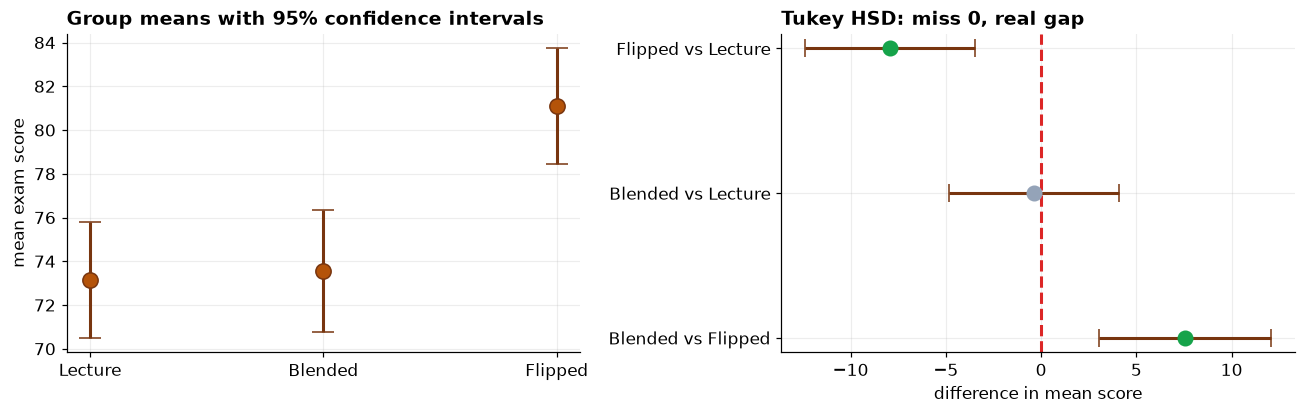

In [10]:
# The result in one picture: group means with 95% CIs, and the Tukey pairwise differences.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.9))
means = [x.mean() for x in groups]
cis = [stats.t.ppf(0.975, len(x)-1)*x.std(ddof=1)/np.sqrt(len(x)) for x in groups]
ax[0].errorbar(ORDER, means, yerr=cis, fmt="o", markersize=10, capsize=7, lw=2,
               color=DARK, markerfacecolor=GOLD, markeredgecolor=DARK)
ax[0].set_ylabel("mean exam score"); ax[0].set_title("Group means with 95% confidence intervals")
labels = [f"{a} vs {b}" for a,b in zip(tuk.groupsunique[tuk._multicomp.pairindices[0]],
                                       tuk.groupsunique[tuk._multicomp.pairindices[1]])]
diffs = tuk.meandiffs; lo = tuk.confint[:,0]; hi = tuk.confint[:,1]
ypos = np.arange(len(diffs))
colors = [GR if r else MUT for r in tuk.reject]
ax[1].errorbar(diffs, ypos, xerr=[diffs-lo, hi-diffs], fmt="o", capsize=6, lw=2, color=DARK, ls="none")
for y, d_, c in zip(ypos, diffs, colors): ax[1].scatter([d_],[y], s=90, color=c, zorder=3)
ax[1].axvline(0, color=RD, lw=2, ls="--")
ax[1].set_yticks(ypos); ax[1].set_yticklabels(labels)
ax[1].set_xlabel("difference in mean score"); ax[1].set_title("Tukey HSD: miss 0, real gap")
plt.tight_layout(); plt.show()

**The picture in one line.** On the left, Flipped's interval sits clear of the other two, which overlap each other almost completely. On the right, the two Flipped comparisons (green) have intervals entirely off the zero line, while the Lecture-versus-Blended interval (gray) straddles zero. Same conclusion, drawn two ways.

## Step 11 &middot; Estimate, do not just test
The ANOVA said the methods differ and Tukey said which. Neither said **by how much**, and the intervals Tukey already computed deserve to be read out loud rather than left as a reject-or-not column.

In [11]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

print(f"{'comparison':22s} {'difference':>11s}  {'95% CI':>18s}   verdict")
print("-"*70)
for lab, dfc, l, h, rej in zip(labels, diffs, lo, hi, tuk.reject):
    print(f"{lab:22s} {dfc:+11.2f}  [{l:+6.2f}, {h:+6.2f}]   {'differs' if rej else 'cannot separate'}")

# An interval for eta-squared, which is otherwise reported as a bare number.
e_lo, e_hi, _ = boot_ci_groups(groups, lambda g: (
    lambda gm: sum(len(x)*(x.mean()-gm)**2 for x in g) /
               (sum(len(x)*(x.mean()-gm)**2 for x in g) + sum(((x-x.mean())**2).sum() for x in g))
)(np.concatenate(g).mean()))
print(f"\neta-squared            {eta2:.3f}        95% CI [{e_lo:.3f}, {e_hi:.3f}]")

# Per-group mean with its own interval, which is what a department head reads.
print()
for m_, g in zip(ORDER, groups):
    moe = stats.t.ppf(0.975, len(g)-1)*g.std(ddof=1)/np.sqrt(len(g))
    print(f"{m_:9s} mean {g.mean():5.2f}   95% CI [{g.mean()-moe:5.2f}, {g.mean()+moe:5.2f}]   n = {len(g)}")

comparison              difference              95% CI   verdict
----------------------------------------------------------------------
Blended vs Flipped           +7.56  [ +3.04, +12.08]   differs
Blended vs Lecture           -0.38  [ -4.83,  +4.07]   cannot separate
Flipped vs Lecture           -7.94  [-12.41,  -3.47]   differs



eta-squared            0.149        95% CI [0.063, 0.279]

Lecture   mean 73.16   95% CI [70.50, 75.81]   n = 45
Blended   mean 73.53   95% CI [70.75, 76.32]   n = 43
Flipped   mean 81.10   95% CI [78.46, 83.73]   n = 42


**The intervals turn a verdict into a size.** Flipped beats Lecture by 7.9 points, but the range consistent with the data runs from about 3.5 to 12.4. A department deciding whether to retrain its staff should be told that range, because a 3-point gain and a 12-point gain justify very different amounts of effort.

**And look at the comparison that failed.** Blended against Lecture is not simply "no difference". Its interval runs from roughly &#8722;4.8 to +4.1, meaning the data are compatible with Blended being nearly 5 points better *or* 4 points worse. That is a genuinely inconclusive result, and it is a different statement from "the two methods are equivalent". An interval says so; a p-value of 0.978 does not.

Eta-squared gets an interval too, and it is wide: teaching method plausibly accounts for anywhere from about 6 to 28 percent of the variation in scores. Reporting 0.15 alone implies a precision 130 students cannot deliver.

## Step 12 &middot; Interpret in plain language
Teaching method matters, but not in the way a naive reading of "significant" would suggest. Students taught with the **Flipped** method scored about **8 points higher** on average than either of the other two, a substantial gap in exam terms. **Lecture and Blended performed the same**, within half a point of each other. So the honest headline is not "the three methods differ" but "one method outperforms, and the other two are equivalent". Method explains about **15%** of the variation in scores, which leaves the large majority to student-level factors the design does not capture.

## Step 13 &middot; Ethics, bias, and limits
- **How were students assigned?** If students chose their section, the comparison is confounded by who chooses what. Motivated students may self-select into a Flipped section, and we would be measuring the students, not the method. Random assignment, or at minimum a check that prior achievement is balanced across methods, is what licenses a causal reading.
- **Who taught which section?** Instructor skill and enthusiasm ride along with method. If one energetic instructor taught all the Flipped sections, method and instructor are inseparable in this design.
- **One outcome is a narrow view.** A final exam measures a particular kind of learning. A method that lifts exam scores may not equally lift retention, transfer, or student wellbeing, and a decision to adopt it should weigh more than one number.
- **Do not over-read the tie.** "Lecture and Blended are statistically indistinguishable" means this study did not detect a difference, not that none exists; a small real difference could hide in this sample size.

---
**From analysis to report.** The notebook carries the evidence: the cleaning trail, the assumption checks, the ANOVA table, the post-hoc comparisons, and the effect size. The written reports turn it into a recommendation a department chair can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.